# Dataset19 — Step 3: Uncalibrated MUSIC

Step 2 produced, for every packet, three 16-element snapshots $\mathbf x$ with the CFO removed and the phase referenced to ANT1. Each element is $x_n = A_n\,e^{\,j(\psi_n - \psi_1)}$, where $\psi_n$ is the spatial phase of antenna $n$.

This notebook turns those snapshots into an angle-of-arrival estimate with the MUSIC algorithm, using only the *ideal* array geometry — no calibration of any kind. The result is a baseline: how well does the textbook method do on this hardware, and where does it fail?

Sections:

1. Load the Step 2 snapshots
2. Array geometry and the steering vector
3. The MUSIC algorithm: covariance, eigen-decomposition, signal and noise subspaces, pseudo-spectrum
4. Worked example on one window of packets
5. The steering-vector sign: the four-way test on reference tags
6. Run on every (set, point) and compare with ground truth
7. Save

## 1. Load the Step 2 snapshots

Step 2 wrote `dataset19_snapshots_meta.csv` (one row per packet) and `dataset19_snapshots.npz` (a (N, 16) complex array for each complete group G2, G3, G4). Run Step 2 first if they are missing.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

meta = pd.read_csv('dataset19_snapshots_meta.csv')
_npz = np.load('dataset19_snapshots.npz')
COMPLETE = ['G2', 'G3', 'G4']
SNAP = {g: _npz[g] for g in COMPLETE}                              # (N, 16) complex, ANT1..16, CFO-removed, ref. ANT1
gt = pd.read_csv('dataset19_ground_truth.csv', index_col='pt')     # from Step 1
assert all(SNAP[g].shape == (len(meta), 16) for g in COMPLETE)
print({g: v.shape for g, v in SNAP.items()})
gt.loc[[1, 25, 49]].round(2)

{'G2': (73000, 16), 'G3': (73000, 16), 'G4': (73000, 16)}


,x,y,z,AZ,EL,role
pt,,,,,,
1,295.0,120.0,120.0,22.14,20.65,ref
25,295.0,0.0,0.0,0.00,0.00,ref
49,295.0,-120.0,-120.0,-22.14,-20.65,ref


## 2. Array geometry and the steering vector

### Frame
Array in the yz-plane, phase centre at the origin. **+x is boresight** (toward the tags), **+z up**, **+y to the tag's right** when the tag faces the array. Angles:

$$ \mathrm{AZ} = \operatorname{atan2}(y, x), \qquad \mathrm{EL} = \operatorname{atan2}\big(z, \sqrt{x^2+y^2}\big) $$

### Antenna positions (tag view: +y right, +z up)

```
             y=-1.5d   y=-0.5d   y=+0.5d   y=+1.5d
z=+1.5d        13         9         5         1
z=+0.5d        14        10         6         2
z=-0.5d        15        11         7         3
z=-1.5d        16        12         8         4
```

Pitch $d = 40$ mm, $\lambda \approx 125$ mm at 2.44 GHz, so $d/\lambda = 0.32$ and one pitch of extra path is $2\pi \cdot 0.32 = 115.2°$ of phase.

### Steering vector
A plane wave from direction (AZ, EL) has unit propagation vector components $u = \cos\mathrm{EL}\sin\mathrm{AZ}$ along $y$ and $v = \sin\mathrm{EL}$ along $z$. Antenna $n$ at $(y_n, z_n)$ (in units of $d$) sees the wave a path $d\,(u\,y_n + v\,z_n)$ earlier than the centre, i.e. a phase

$$ \psi_n(\mathrm{AZ},\mathrm{EL}) = 2\pi\frac{d}{\lambda}\left(s_y\, u\, y_n + s_z\, v\, z_n\right), \qquad a_n = e^{\,j\psi_n} $$

The vector $\mathbf a(\mathrm{AZ},\mathrm{EL}) = [a_1, \dots, a_{16}]^T$ is the **steering vector**: the phase pattern an ideal array would show for that direction. *Appendix I* (`plane_wave.pdf`, and the companion notebook `wave_direction.ipynb`) derives this from $\cos(2\pi f t - \mathbf k\cdot\mathbf r)$, including why the sign of $\psi_n$ is positive for an element displaced toward the source.

$s_y, s_z \in \{+1, -1\}$ are sign factors. Physically they should both be $+1$, but the capture chain (I/Q mixer convention, phase sign of the recorded samples) can flip the sign of every measured phase, which is indistinguishable from negating both antenna coordinates. On every dataset from this board so far the data required $(s_y, s_z) = (-1, -1)$; Section 5 verifies it on this one rather than assuming it.

In [2]:
_layout = [[13, 9, 5, 1],
           [14,10, 6, 2],
           [15,11, 7, 3],
           [16,12, 8, 4]]                       # rows top->bottom, cols left->right, tag view
_y_pos  = [-1.5, -0.5, +0.5, +1.5]             # units of d
_z_pos  = [+1.5, +0.5, -0.5, -1.5]
ANT_POS = {ant: (_y_pos[ci], _z_pos[ri]) for ri, row in enumerate(_layout) for ci, ant in enumerate(row)}
ANT_Y = np.array([ANT_POS[n][0] for n in range(1, 17)])
ANT_Z = np.array([ANT_POS[n][1] for n in range(1, 17)])
D_OVER_LAMBDA = 0.32

def steering(az_deg, el_deg, sy, sz):
    """Steering vectors for arrays of angles. Returns (..., 16) complex, phase referenced to ANT1."""
    az, el = np.radians(np.asarray(az_deg, float)), np.radians(np.asarray(el_deg, float))
    u = np.cos(el) * np.sin(az)
    v = np.sin(el)
    psi = 2*np.pi*D_OVER_LAMBDA * (sy * u[..., None] * ANT_Y + sz * v[..., None] * ANT_Z)
    a = np.exp(1j * psi)
    return a * np.conj(a[..., [0]])              # reference to ANT1, like the snapshots

# example: phase pattern for a tag 10° to the right, 5° up, in the (+1,+1) convention
np.round(np.degrees(np.angle(steering(10, 5, +1, +1))), 1).reshape(4, 4).T

array([[  0. , -19.9, -39.9, -59.8],
       [-10. , -30. , -49.9, -69.8],
       [-20.1, -40. , -59.9, -79.9],
       [-30.1, -50. , -70. , -89.9]])

(The 4×4 print above is arranged as ANT1–4 in the first row, ANT5–8 in the second, …; a linear ramp along $y$ from AZ and along $z$ from EL, as it should be.)

### Search grid
MUSIC evaluates a pseudo-spectrum on a grid of candidate directions and picks the peak. The tags span about ±17° in both axes; a ±40° × ±30° grid at 0.5° covers that with margin. The steering matrix $\mathbf A$ (grid points × 16) is computed once per sign convention.

In [3]:
AZ_GRID = np.arange(-40, 40.01, 0.5)
EL_GRID = np.arange(-30, 30.01, 0.5)
AZm, ELm = np.meshgrid(AZ_GRID, EL_GRID)              # (nEL, nAZ)

def steering_matrix(sy, sz):
    return steering(AZm.ravel(), ELm.ravel(), sy, sz)  # (nEL*nAZ, 16)

print(f'grid: {len(EL_GRID)} EL x {len(AZ_GRID)} AZ = {AZm.size} directions')

grid: 121 EL x 161 AZ = 19481 directions


## 3. The MUSIC algorithm

### Signal model
With one tag and no multipath, every snapshot is the steering vector of the true direction, scaled by a complex amplitude $s$, plus noise:

$$ \mathbf x_m = \mathbf a(\mathrm{AZ}_0, \mathrm{EL}_0)\, s_m + \mathbf n_m, \qquad m = 1\dots M $$

The 16 antennas give a vector in $\mathbb C^{16}$; the signal lives entirely along one direction in that space ($\mathbf a$), the noise spreads over all 16.

### Covariance
Stack $M$ snapshots as columns of $\mathbf X$ (16 × M). The superscript $^H$ is the **Hermitian transpose** (conjugate transpose): $\mathbf X^H = (\bar{\mathbf X})^T$ — transpose, then conjugate every entry. For one snapshot, $\mathbf x\mathbf x^H$ is the 16×16 matrix with $(m,n)$ entry $x_m\bar x_n = A_mA_n\,e^{\,j(\psi_m-\psi_n)}$: the amplitude product and the **phase difference** between antennas $m$ and $n$ — exactly the direction-carrying quantity from Step 2. (For real vectors $^H$ is just $^T$; for complex ones $\mathbf x^T\mathbf x$ would *add* phases and is meaningless here.) The sample covariance averages these outer products:

$$ \mathbf R = \frac{1}{M}\,\mathbf X\,\mathbf X^{H} = \sigma_s^2\,\mathbf a\mathbf a^{H} + \sigma_n^2\,\mathbf I \quad (16\times16) $$

The order matters: $\mathbf X\mathbf X^H$ gives $\mathbf R$; $\mathbf X^H\mathbf X$ (or, for snapshots stored as rows, `X.conj().T @ X`) gives $\mathbf R^*$, whose peak appears at the mirror direction. With snapshots stored as rows of an (M, 16) array the correct call is `X.T @ X.conj()`.

### Eigen-decomposition
A matrix is **Hermitian** if $\mathbf R^H = \mathbf R$: entry $(n,m)$ is the conjugate of entry $(m,n)$, the diagonal is real. $\mathbf R$ is Hermitian by construction ($R_{mn} = \langle x_m\bar x_n\rangle$, so swapping indices conjugates it; $R_{nn}$ is the mean power on antenna $n$). Hermitian matrices are the complex analogue of real symmetric matrices: all eigenvalues real, eigenvectors orthonormal.

So $\mathbf R$ has 16 real eigenvalues $\lambda_1 \ge \dots \ge \lambda_{16} \ge 0$. They are non-negative because $\mathbf e^H\mathbf R\mathbf e = \frac1M\sum_m|\mathbf e^H\mathbf x_m|^2 \ge 0$, and they can be **exactly zero**: with $M < 16$ snapshots $\mathbf R$ has rank ≤ M and at least $16-M$ eigenvalues vanish; a noiseless single source would give rank one. Noise lifts the small eigenvalues to about $\sigma_n^2$, but this is why $M > 16$ is required — with too few snapshots some noise eigenvectors are arbitrary and the noise subspace is not determined by the data.

For one source in white noise: $\lambda_1 = 16\sigma_s^2 + \sigma_n^2$ along $\mathbf e_1 \parallel \mathbf a$, and $\lambda_2 = \dots = \lambda_{16} = \sigma_n^2$ in the 15-dimensional space orthogonal to $\mathbf a$.

- **Signal subspace**: $\mathbf e_1$ — the array's *measured* phase pattern for this tag
- **Noise subspace**: $\mathbf E_n = [\mathbf e_2 \dots \mathbf e_{16}]$ (16 × 15), orthogonal to $\mathbf a$

The ratio $\lambda_1/\lambda_2$ tells how single-path the window is: a second arrival of comparable strength lifts $\lambda_2$ and collapses the ratio.

### Pseudo-spectrum
Because the true $\mathbf a$ is orthogonal to every noise eigenvector, $\|\mathbf E_n^H \mathbf a(\mathrm{AZ}_0,\mathrm{EL}_0)\|^2 \approx 0$, while for any other direction it is not. MUSIC therefore scans the grid with

$$ P(\mathrm{AZ}, \mathrm{EL}) = \frac{1}{\|\mathbf E_n^{H}\,\mathbf a(\mathrm{AZ},\mathrm{EL})\|^2} $$

and reports the direction of the maximum.

**An implementation trap.** The $i$-th entry of $\mathbf E_n^H\mathbf a$ is $\sum_n \overline{(e_{i+1})_n}\,a_n$ — exactly one of the two factors carries a conjugate. In `music()` below the steering vectors are the *rows* of `A` (row $m$ is $\mathbf a_m^T$, unconjugated) and `En` is 16 × 15, so `A @ En` has entry $\sum_n (a_m)_n (e_{i+1})_n$ with **neither** factor conjugated. That equals $\overline{\mathbf e_{i+1}^H\bar{\mathbf a}_m}$: it evaluates the spectrum at the *conjugate* steering vectors, and $\bar{\mathbf a}(\mathrm{AZ},\mathrm{EL})$ has phases $-\psi_n$, i.e. it is the steering vector of $(-\mathrm{AZ},-\mathrm{EL})$. The whole spectrum comes out reflected through boresight, with an equally sharp peak and the same eigenvalue ratio. The correct call is `conj(A) @ En`. This is the second route to a mirrored answer (the first is the covariance order above); the two cancel if both are made; neither raises any warning. Only a test against known positions — Section 5 — catches them, because to the estimator a conjugation error and a sign error in the antenna table are the same thing.

Note that MUSIC needs $M > 16$ snapshots for $\mathbf R$ to have full rank, and works best with $M \gg 16$; with 3 snapshots per packet a window of 50 packets gives 150.

In [4]:
def covariance(X):
    """X: (M, 16) snapshots as rows -> R (16, 16) = (1/M) sum_m x_m x_m^H."""
    return X.T @ X.conj() / X.shape[0]

def music(X, A, n_src=1):
    """X: (M,16) snapshots. A: (nGrid,16) steering matrix. Returns (az, el, spectrum(nEL,nAZ), eigvals)."""
    R = covariance(X)
    lam, E = np.linalg.eigh(R)                    # ascending
    lam, E = lam[::-1], E[:, ::-1]                # descending
    En = E[:, n_src:]                             # (16, 15) noise subspace
    proj = np.conj(A) @ En                        # (nGrid, 15): row m = a_m^H En  (conj is essential: A @ En would give En^T a,
                                                  #  i.e. the spectrum for conj(a), which mirrors both angles)
    P = 1.0 / np.sum(np.abs(proj)**2, axis=1)
    P = P.reshape(AZm.shape)
    i = np.unravel_index(np.argmax(P), P.shape)
    return AZm[i], ELm[i], P, lam

def window_snapshots(idx):
    """Stack the G2/G3/G4 snapshots of the packets at integer positions idx -> (3*len(idx), 16)."""
    return np.concatenate([SNAP[g][idx] for g in COMPLETE], axis=0)

## 4. Worked example on one window

### 4.1 A well-behaved point: pt46

Take the first 50 packets of the tag at **pt46** in set1 (a reference tag, bottom row, one column right of centre; ground truth AZ = −7.7°, EL = −13.7°). Use the convention every previous dataset required, $(s_y, s_z) = (-1, -1)$, and see what comes out. Section 5 then checks that choice properly.

In [5]:
SY, SZ = -1, -1
A = steering_matrix(SY, SZ)

sel = meta.index[(meta.set == 'set1') & (meta.pt == 46)][:50]
X = window_snapshots(sel)
az_hat, el_hat, P, lam = music(X, A)
gt_az, gt_el = gt.loc[46, ['AZ', 'EL']]

print(f'window: {len(sel)} packets -> {X.shape[0]} snapshots, channels {meta.channel[sel].nunique()}, RSSI mean {meta.rssi[sel].mean():.1f} dBm')
print(f'eigenvalues (first 5, normalised to λ1): {np.round(lam[:5]/lam[0], 4)}')
print(f'λ1/λ2 = {lam[0]/lam[1]:.1f}')
print(f'MUSIC peak : AZ = {az_hat:6.1f}°, EL = {el_hat:6.1f}°')
print(f'ground truth: AZ = {gt_az:6.1f}°, EL = {gt_el:6.1f}°')
print(f'error      : AZ = {az_hat-gt_az:+6.1f}°, EL = {el_hat-gt_el:+6.1f}°')

window: 50 packets -> 150 snapshots, channels 29, RSSI mean -59.1 dBm
eigenvalues (first 5, normalised to λ1): [1.     0.1863 0.0448 0.0303 0.0149]
λ1/λ2 = 5.4
MUSIC peak : AZ =   -3.0°, EL =  -16.5°
ground truth: AZ =    0.0°, EL =  -22.1°
error      : AZ =   -3.0°, EL =   +5.6°


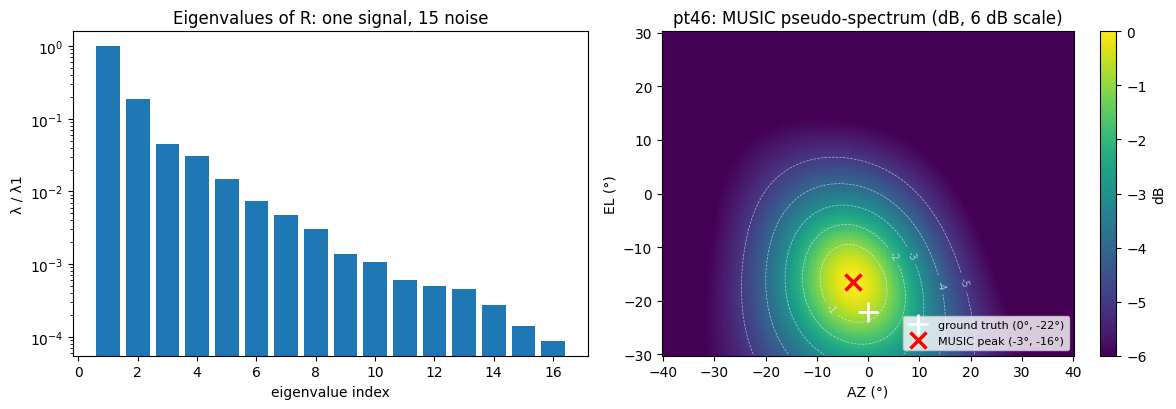

spectrum at survey direction: -0.7 dB below peak;  full range of spectrum: 6.7 dB


In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
ax[0].bar(range(1, 17), lam / lam[0]); ax[0].set_yscale('log')
ax[0].set_xlabel('eigenvalue index'); ax[0].set_ylabel('λ / λ1'); ax[0].set_title('Eigenvalues of R: one signal, 15 noise')
def plot_spectrum(ax, P, gt_az, gt_el, az_hat, el_hat, title):
    PdB = 10*np.log10(P / P.max())
    im = ax.pcolormesh(AZ_GRID, EL_GRID, PdB, vmin=-6, vmax=0, cmap='viridis', shading='auto')
    cs = ax.contour(AZ_GRID, EL_GRID, PdB, levels=[-5, -4, -3, -2, -1], colors='w', linewidths=0.5, alpha=0.6)
    ax.clabel(cs, fmt='%d', fontsize=7)
    ax.plot(gt_az, gt_el, 'w+', ms=14, mew=2, label=f'ground truth ({gt_az:.0f}°, {gt_el:.0f}°)')
    ax.plot(az_hat, el_hat, 'rx', ms=12, mew=2.5, label=f'MUSIC peak ({az_hat:.0f}°, {el_hat:.0f}°)')
    ax.set_xlabel('AZ (°)'); ax.set_ylabel('EL (°)'); ax.set_title(title); ax.legend(loc='lower right', fontsize=8)
    return im

im = plot_spectrum(ax[1], P, gt_az, gt_el, az_hat, el_hat, 'pt46: MUSIC pseudo-spectrum (dB, 6 dB scale)')
plt.colorbar(im, ax=ax[1], label='dB'); plt.tight_layout(); plt.show()
i_gt = (np.abs(AZm - gt_az) + np.abs(ELm - gt_el)).argmin()
print(f'spectrum at survey direction: {10*np.log10(P.ravel()[i_gt]/P.max()):.1f} dB below peak;  full range of spectrum: {10*np.log10(P.max()/P.min()):.1f} dB')

The spectrum has a single lobe and the survey direction lies inside it (only 0.7 dB below the top), 6° from the peak. Note the colour scale: the whole spectrum spans only ~7 dB. Uncalibrated MUSIC never produces deep nulls on this array, because the element errors shown below keep the ideal steering vector from being orthogonal to the noise subspace anywhere. That residual is what the later calibration steps are about; here the point is that geometry alone already puts the estimate in the right place.

### Compare: measured snapshot vs. ideal steering vector

The principal eigenvector $\mathbf e_1$ is the array's *measured* phase pattern for this tag. Put it beside the ideal steering vector at the ground-truth direction:

In [7]:
R = covariance(X); lam_, E_ = np.linalg.eigh(R); e1 = E_[:, -1]
e1 = e1 * np.conj(e1[0]) / abs(e1[0])                         # reference to ANT1
a_gt = steering(gt_az, gt_el, SY, SZ)
cmp = pd.DataFrame({'measured e1 phase': np.degrees(np.angle(e1)),
                    'ideal a(gt) phase': np.degrees(np.angle(a_gt)),
                    'difference': np.degrees(np.angle(e1 * np.conj(a_gt))),
                    '|e1| (norm.)': np.abs(e1) / np.abs(e1).max()},
                   index=pd.Index(range(1, 17), name='ant')).round(1)
cmp.T

ant,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
measured e1 phase,0.0,-22.2,-56.2,-61.0,17.7,-37.0,-50.8,-109.7,60.6,-40.7,-36.0,-108.9,-6.6,-49.6,-77.5,-104.9
ideal a(gt) phase,-0.0,-43.4,-86.8,-130.2,-0.0,-43.4,-86.8,-130.2,-0.0,-43.4,-86.8,-130.2,-0.0,-43.4,-86.8,-130.2
difference,0.0,21.2,30.6,69.3,17.7,6.4,36.0,20.5,60.6,2.7,50.8,21.3,-6.6,-6.2,9.3,25.4
|e1| (norm.),1.0,0.5,0.6,0.4,0.4,0.4,0.4,0.1,0.5,0.4,0.5,0.3,0.7,0.5,0.6,0.8


Because this tag is at AZ = 0, the ideal pattern is the same down every column and constant along every row. The measured pattern follows the down-column ramp with a *shallower slope* (hence the elevation error) and is *not* constant along rows (ANT5, ANT9 read +18°, +61° where the ideal is 0). Those residuals — per-element phase offsets, mutual coupling, possibly a weak second arrival — are what calibration is for.

### 4.2 A problematic point: pt42

Same procedure on the point that fails worst in the full run: pt42, bottom row, far left (survey AZ = −22.1°, EL = −14.1°), recorded in set7.

window: 50 packets -> 150 snapshots, tag 84:2e:14:31:b6:f2, channels 29, RSSI mean -63.8 dBm  (pt46: -59.1)
eigenvalues (first 5, normalised): [1.     0.2732 0.0846 0.023  0.0183]    λ1/λ2 = 3.7  (pt46: 5.4)
MUSIC peak : AZ =  -15.0°, EL =   27.0°
ground truth: AZ =  -22.1°, EL =  -14.1°
error      : AZ =   +7.1°, EL =  +41.1°
spectrum at survey direction: -5.5 dB below peak;  full range: 5.5 dB


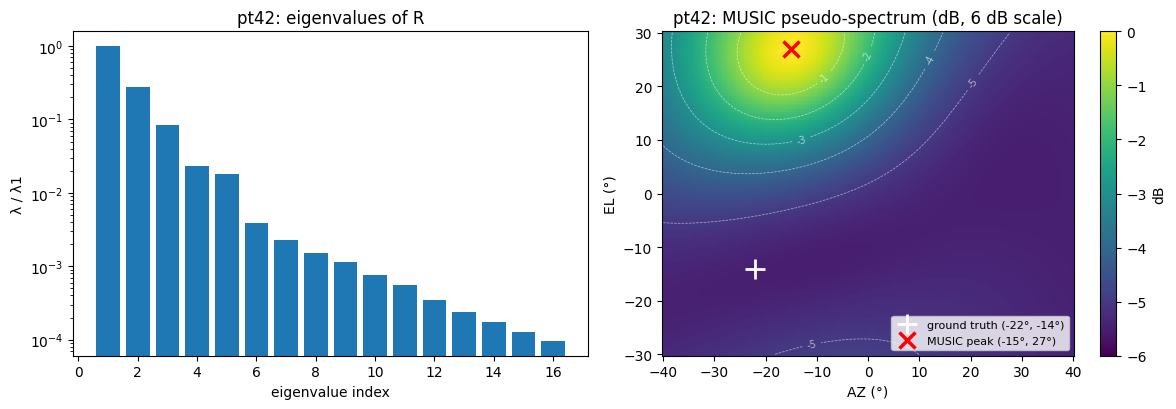

In [8]:
sel42 = meta.index[(meta.set == 'set7') & (meta.pt == 42)][:50]
X42 = window_snapshots(sel42)
az42, el42, P42, lam42 = music(X42, A)
gt_az42, gt_el42 = gt.loc[42, ['AZ', 'EL']]

print(f'window: {len(sel42)} packets -> {X42.shape[0]} snapshots, tag {meta.address[sel42].iloc[0]}, channels {meta.channel[sel42].nunique()}, RSSI mean {meta.rssi[sel42].mean():.1f} dBm  (pt46: {meta.rssi[sel].mean():.1f})')
print(f'eigenvalues (first 5, normalised): {np.round(lam42[:5]/lam42[0], 4)}    λ1/λ2 = {lam42[0]/lam42[1]:.1f}  (pt46: {lam[0]/lam[1]:.1f})')
print(f'MUSIC peak : AZ = {az42:6.1f}°, EL = {el42:6.1f}°')
print(f'ground truth: AZ = {gt_az42:6.1f}°, EL = {gt_el42:6.1f}°')
print(f'error      : AZ = {az42-gt_az42:+6.1f}°, EL = {el42-gt_el42:+6.1f}°')
i_gt = (np.abs(AZm - gt_az42) + np.abs(ELm - gt_el42)).argmin()
print(f'spectrum at survey direction: {10*np.log10(P42.ravel()[i_gt]/P42.max()):.1f} dB below peak;  full range: {10*np.log10(P42.max()/P42.min()):.1f} dB')

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
ax[0].bar(range(1, 17), lam42 / lam42[0]); ax[0].set_yscale('log')
ax[0].set_xlabel('eigenvalue index'); ax[0].set_ylabel('λ / λ1'); ax[0].set_title('pt42: eigenvalues of R')
im = plot_spectrum(ax[1], P42, gt_az42, gt_el42, az42, el42, 'pt42: MUSIC pseudo-spectrum (dB, 6 dB scale)')
plt.colorbar(im, ax=ax[1], label='dB'); plt.tight_layout(); plt.show()

Everything about this window says *two arrivals*: λ₂ is 27% of λ₁ (19% for pt46), so the second eigenvector carries signal; the survey direction sits at the bottom of the valley, 5.5 dB down in a spectrum whose whole range is 5.5 dB; a second lobe appears on the bottom edge; and the peak is on the wrong side of the horizon. It is also stable — every window of pt42 gives EL ≈ +29° — so this is not noise.

The measured phase pattern shows what is happening:

In [9]:
R42 = covariance(X42); _, E42 = np.linalg.eigh(R42); e1_42 = E42[:, -1]
e1_42 = e1_42 * np.conj(e1_42[0]) / abs(e1_42[0])
a_gt42 = steering(gt_az42, gt_el42, SY, SZ)
cmp42 = pd.DataFrame({'measured e1 phase': np.degrees(np.angle(e1_42)),
                      'ideal a(survey) phase': np.degrees(np.angle(a_gt42)),
                      'difference': np.degrees(np.angle(e1_42 * np.conj(a_gt42))),
                      '|e1| (norm.)': np.abs(e1_42) / np.abs(e1_42).max()},
                     index=pd.Index(range(1, 17), name='ant')).round(1)
cmp42.T

ant,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
measured e1 phase,0.0,17.2,43.7,84.9,-87.1,-94.7,8.6,47.9,-111.0,-101.9,-8.9,39.3,-157.9,-94.5,-33.5,70.4
ideal a(survey) phase,-0.0,-28.1,-56.1,-84.2,-42.1,-70.2,-98.2,-126.3,-84.2,-112.3,-140.3,-168.4,-126.3,-154.4,177.6,149.5
difference,0.0,45.3,99.8,169.1,-45.0,-24.5,106.8,174.2,-26.8,10.3,131.4,-152.3,-31.6,59.9,149.0,-79.1
|e1| (norm.),0.5,0.3,0.5,1.0,0.5,0.6,0.5,0.8,0.7,0.8,0.7,0.8,0.7,0.5,0.3,0.6


In [10]:
print('vertical phase gradient, top -> bottom of each column (ANT1-4, 5-8, 9-12, 13-16):')
for c0 in [0, 4, 8, 12]:
    meas = np.degrees(np.angle(e1_42[c0:c0+4] * np.conj(e1_42[c0])))
    ideal = np.degrees(np.angle(a_gt42[c0:c0+4] * np.conj(a_gt42[c0])))
    print(f'  ANT{c0+1:>2}-{c0+4:<2}  measured {np.round(meas,0)}   ideal {np.round(ideal,0)}')

vertical phase gradient, top -> bottom of each column (ANT1-4, 5-8, 9-12, 13-16):
  ANT 1-4   measured [ 0. 17. 44. 85.]   ideal [  0. -28. -56. -84.]
  ANT 5-8   measured [  0.  -8.  96. 135.]   ideal [  0. -28. -56. -84.]
  ANT 9-12  measured [  0.   9. 102. 150.]   ideal [  0. -28. -56. -84.]
  ANT13-16  measured [   0.   63.  124. -132.]   ideal [ -0. -28. -56. -84.]


Read down any column. The survey direction, below the horizon, requires the phase to **fall**: 0, −28, −56, −84. The measured phase **rises**: 0, +17, +44, +85 — same magnitude, opposite sign, in every column. The array is reporting a wave arriving from *above*, which is exactly what a specular ceiling reflection produces: an image of the tag at height $2h_\mathrm{ceiling} - z_\mathrm{tag}$, seen at positive elevation. At pt42 the direct path is weak (lowest RSSI on the grid) and the ceiling image is comparable in strength; the single-source covariance mixes the two and MUSIC follows the stronger. The 7° AZ error is the same effect — the image is at a slightly different azimuth, and the mixture peaks between.

Contrast with pt46: there the differences were tens of degrees and irregular — element errors on a correctly-signed gradient. Here the gradient itself is inverted along $z$, which no per-element calibration can repair. pt42 fails with a different tag in each earlier dataset from this room: a property of the location, not of the tag or the array.

## 5. The steering-vector sign: four-way test

The sign factors $(s_y, s_z)$ cannot be derived; they are measured. Run MUSIC with all four combinations on every **reference tag** (fixed, known position, present in all sets) and pick the combination that agrees with the survey. The two axes separate cleanly because $s_y$ only affects AZ and $s_z$ only EL.

For each reference point, all packets of set1–set7 are used in windows of 50 packets and the median estimate is compared to ground truth.

In [11]:
REF_PTS = [1, 4, 7, 15, 21, 25, 29, 35, 43, 46, 49]
WIN = 50

def windows_for(mask, win=WIN):
    idx = meta.index[mask].to_numpy()
    return [idx[i:i+win] for i in range(0, len(idx) - win + 1, win)]

results = []
for sy, sz in [(+1, +1), (+1, -1), (-1, +1), (-1, -1)]:
    A_ = steering_matrix(sy, sz)
    for pt in REF_PTS:
        ests = [music(window_snapshots(w), A_)[:2] for w in windows_for((meta.pt == pt) & (meta.set != 'test'))]
        ests = np.array(ests)
        results.append(dict(sy=sy, sz=sz, pt=pt, n_win=len(ests),
                            az_med=np.median(ests[:, 0]), el_med=np.median(ests[:, 1])))
res = pd.DataFrame(results).merge(gt[['AZ', 'EL']], left_on='pt', right_index=True)
res['az_err'] = res.az_med - res.AZ; res['el_err'] = res.el_med - res.EL

four_way = res.groupby(['sy', 'sz']).agg(AZ_MAE=('az_err', lambda e: e.abs().mean()),
                                         EL_MAE=('el_err', lambda e: e.abs().mean())).round(2)
four_way

AZ_MAE  EL_MAE
sy sz                
-1 -1    2.18    2.62
    1    2.18   28.36
 1 -1   33.03    2.62
    1   33.03   28.36

Read the table: flipping $s_y$ only moves the AZ column and flipping $s_z$ only the EL column, so the winning combination is unambiguous. A large AZ error for one $s_y$ means MUSIC returned $-\mathrm{AZ}$ for that sign (the boresight tag pt25 alone could never show this; the corners can).

In [12]:
best = four_way.sum(axis=1).idxmin()
SY, SZ = best
print(f'selected (SY, SZ) = ({SY:+d}, {SZ:+d})')
A = steering_matrix(SY, SZ)

# per-point view under the selected convention
(res[(res.sy == SY) & (res.sz == SZ)]
   .set_index('pt')[['n_win', 'AZ', 'az_med', 'az_err', 'EL', 'el_med', 'el_err']].round(1))

selected (SY, SZ) = (-1, -1)


,n_win,AZ,az_med,az_err,EL,el_med,el_err
pt,,,,,,,
1,81,22.1,20.5,-1.6,20.6,20.5,-0.1
4,108,0.0,0.0,0.0,22.1,22.0,-0.1
7,70,-22.1,-24.0,-1.9,20.6,22.5,1.9
15,108,22.1,18.5,-3.6,7.2,15.0,7.8
21,78,-22.1,-23.5,-1.4,7.2,10.5,3.3
25,123,0.0,-2.5,-2.5,0.0,-1.0,-1.0
29,90,22.1,23.8,1.6,-7.2,-4.0,3.2
35,101,-22.1,-20.0,2.1,-7.2,-1.5,5.7
43,126,22.1,25.5,3.4,-20.6,-21.5,-0.9


## 6. Run on every (set, point)

Now the full dataset: every (set, grid point) combination, windows of 50 packets, MUSIC with the selected sign convention. Reference points appear in every set (a repeatability check); tracking points appear in one set each.

In [13]:
rows = []
for (s, pt), grp in meta.groupby(['set', 'pt']):
    wins = windows_for((meta.set == s) & (meta.pt == pt))
    for wi, w in enumerate(wins):
        az_hat, el_hat, _, lam = music(window_snapshots(w), A)
        rows.append(dict(set=s, pt=pt, win=wi, n_pkt=len(w), az_hat=az_hat, el_hat=el_hat,
                         ratio=lam[0]/lam[1], rssi=meta.rssi[w].mean()))
est = pd.DataFrame(rows).merge(gt[['AZ', 'EL', 'role']], left_on='pt', right_index=True)
est['az_err'] = est.az_hat - est.AZ; est['el_err'] = est.el_hat - est.EL
print(f'{len(est)} windows over {est.groupby(["set","pt"]).ngroups} (set, point) combinations')
est.head()

1404 windows over 116 (set, point) combinations


,set,pt,win,n_pkt,az_hat,el_hat,ratio,rssi,AZ,EL,role,az_err,el_err
0,set1,1,0,50,20.5,20.5,32.715358,-54.92,22.135492,20.646315,ref,-1.635492,-0.146315
1,set1,1,1,50,20.5,20.5,31.228585,-55.40,22.135492,20.646315,ref,-1.635492,-0.146315
2,set1,1,2,50,20.5,20.5,31.726387,-54.66,22.135492,20.646315,ref,-1.635492,-0.146315
3,set1,1,3,50,20.5,21.0,32.413495,-54.38,22.135492,20.646315,ref,-1.635492,0.353685
4,set1,1,4,50,21.0,21.0,33.986052,-53.84,22.135492,20.646315,ref,-1.135492,0.353685


In [14]:
per_pt = (est.groupby('pt')
            .agg(role=('role', 'first'), n_win=('win', 'size'),
                 AZ=('AZ', 'first'), az_med=('az_hat', 'median'), az_err=('az_err', 'median'), az_std=('az_hat', 'std'),
                 EL=('EL', 'first'), el_med=('el_hat', 'median'), el_err=('el_err', 'median'), el_std=('el_hat', 'std'),
                 ratio=('ratio', 'median'), rssi=('rssi', 'mean'))
            .round(1))
pd.set_option('display.max_rows', 60)
per_pt

,role,n_win,AZ,az_med,az_err,az_std,EL,el_med,el_err,el_std,ratio,rssi
pt,,,,,,,,,,,,
1,ref,89,22.1,20.5,-1.6,0.4,20.6,21.0,0.4,0.3,34.0,-54.4
4,ref,107,0.0,0.0,0.0,0.2,22.1,22.0,-0.1,0.2,43.9,-45.0
7,ref,69,-22.1,-24.0,-1.9,0.3,20.6,22.5,1.9,0.2,58.4,-46.0
8,grid,7,22.1,24.0,1.9,0.4,14.1,21.0,6.9,0.4,11.6,-52.2
11,grid,24,0.0,0.0,0.0,0.5,15.2,5.0,-10.2,0.5,6.8,-54.7
13,grid,12,-15.2,-16.5,-1.3,0.3,14.7,10.0,-4.7,0.7,54.6,-48.1
14,grid,28,-22.1,-22.5,-0.4,0.4,14.1,8.0,-6.1,0.8,13.1,-46.4
15,ref,108,22.1,18.5,-3.6,0.3,7.2,15.0,7.8,0.2,27.7,-49.3
18,grid,35,0.0,-1.0,-1.0,0.4,7.7,-7.5,-15.2,0.7,5.3,-57.5


In [15]:
print('median-of-window errors over all points:')
print(f"  AZ: MAE {per_pt.az_err.abs().mean():.2f}°, median |err| {per_pt.az_err.abs().median():.2f}°, worst {per_pt.az_err.abs().max():.1f}° at pt{per_pt.az_err.abs().idxmax()}")
print(f"  EL: MAE {per_pt.el_err.abs().mean():.2f}°, median |err| {per_pt.el_err.abs().median():.2f}°, worst {per_pt.el_err.abs().max():.1f}° at pt{per_pt.el_err.abs().idxmax()}")
print(f"  window-to-window std (median over points): AZ {per_pt.az_std.median():.1f}°, EL {per_pt.el_std.median():.1f}°")

median-of-window errors over all points:
  AZ: MAE 2.08°, median |err| 1.90°, worst 6.9° at pt42
  EL: MAE 6.77°, median |err| 5.30°, worst 43.6° at pt42
  window-to-window std (median over points): AZ 0.4°, EL 0.5°


### Reading the results

Three patterns stand out in the table and are worth naming now, because the next steps address them.

- **Azimuth is good everywhere except one point.** Median |AZ error| ≈ 1.9°, and it does not vary much with position. The exception is pt42 (bottom row, far left), 6.9° off.
- **Elevation has a row-dependent bias.** The middle rows (EL ≈ ±7°, 0°) read 3–8° too high; the bottom row (EL ≈ −15°) reads 5–11° too *low*; the top row is nearly unbiased. A bias that depends on the tag's height above the floor, not on azimuth, points at a specular reflection from floor or ceiling adding a second arrival close to the direct path.
- **Two points are mirrored in elevation.** pt42 (survey EL −14.1°, MUSIC +29.5°) and pt18 (survey +7.7°, MUSIC −7.5°). Their eigenvalue ratios are among the lowest (4.2 and 5.3), so the covariance has two arrivals of similar strength and MUSIC has picked the wrong one. These are location effects: the same points fail with different tags in the earlier datasets.

Window-to-window standard deviation is only 0.4–0.5°, so none of this is noise. The errors are systematic, which is what makes them correctable.

**What "correctable" means, and what it costs.** Systematic means the error is a fixed function of *where* the tag is, not of *when* you look — so it can be measured once and removed. The three error types above each have a route, with different appetite for ground truth:

| error type (points) | route | GT to build | GT to use | limit on transfer |
|---|---|---|---|---|
| irregular per-element offsets (pt46) | per-element gain/phase vector $\mathbf g$, fit jointly on reference tags, *after* CFO removal | a few known tags | none | array property — should survive moving the array, if it really is element error |
| smooth row-dependent bias (rows 3–5) | empirical manifold: library of measured $\mathbf e_1$ at known points, match new snapshots to it | a dense grid | none | room + array position only; a 4° array shift invalidated it between D15 and D16 |
| discrete second arrival (pt18, pt42) | image model: 2-source MUSIC + pick below horizon, or fit direct+image with ceiling height as parameter | none (room dimensions) | none | model must hold (flat specular surfaces); GT only verifies |
| any | eigenvalue-ratio gate | none | none | corrects nothing; declines to answer |

Ground truth is needed **once, to build** the correction — not each time it is used — and the true test of any of them is the error on the *tracking* tags, which were held out, not on the reference tags a manifold reproduces by construction. That is why this dataset has both. The manifold is the strongest corrector on the reference points and the weakest generaliser; quantifying that trade-off (how many known points, at what spacing, buy how much on held-out points) is the paper's question.

### Does amplitude normalisation help?

Antenna amplitudes in a snapshot range from ~12 to ~115. Should the snapshots be normalised before the covariance? Five treatments on every window:

In [16]:
def run_all(transform, label):
    rows = []
    for (s_, pt), _ in meta.groupby(['set', 'pt']):
        for w in windows_for((meta.set == s_) & (meta.pt == pt)):
            az_h, el_h, _, lam_ = music(transform(window_snapshots(w)), A)
            rows.append(dict(pt=pt, az=az_h, el=el_h, ratio=lam_[0]/lam_[1]))
    r = pd.DataFrame(rows).groupby('pt').median().join(gt[['AZ', 'EL']])
    return pd.Series({'AZ MAE': (r.az - r.AZ).abs().mean(), 'EL MAE': (r.el - r.EL).abs().mean(),
                      'EL MAE excl pt18,42': (r.el - r.EL).abs().drop([18, 42]).mean(),
                      'median λ1/λ2': r.ratio.median()}, name=label)

amp_mean = np.mean([np.abs(SNAP[g]).mean(0) for g in COMPLETE], axis=0)
eps = 1e-9
norm_test = pd.concat([
    run_all(lambda X: X,                                              'raw (used above)'),
    run_all(lambda X: X / np.maximum(np.abs(X), eps),                 'phase-only  x_n/|x_n|'),
    run_all(lambda X: X / np.linalg.norm(X, axis=1, keepdims=True),   'per-snapshot  x/||x||'),
    run_all(lambda X: X / amp_mean,                                   'per-antenna gain eq.  x_n/<|x_n|>'),
    run_all(lambda X: np.sqrt(np.abs(X)) * np.exp(1j*np.angle(X)),    'sqrt amplitude'),
], axis=1).T.round(2)
norm_test

,AZ MAE,EL MAE,"EL MAE excl pt18,42",median λ1/λ2
raw (used above),2.07,6.77,4.81,13.12
phase-only x_n/|x_n|,2.29,6.71,4.77,18.16
per-snapshot x/||x||,2.11,6.81,4.82,13.07
per-antenna gain eq. x_n/<|x_n|>,2.23,6.86,4.85,11.93
sqrt amplitude,2.11,6.69,4.74,15.57


No treatment moves any point by more than ~1.5°, pt18 and pt42 stay mirrored under all five, and the row bias is untouched. Three things follow:

- MUSIC does not fit amplitudes. The noise subspace is fixed by the *direction* of $\mathbf e_1$ in $\mathbb C^{16}$, which is dominated by its phase pattern; real per-antenna scaling leaves the phases alone. The residual errors are therefore **phase** errors — the shallow ramp and the inverted gradient of Section 4 — and no amplitude weighting can touch them.
- The raw covariance already weights each element by $|x_n|^2$, close to the inverse-variance optimum given Step 2's finding that phase noise scales as $1/|x_n|$. Phase-only normalisation discards that (worst AZ MAE) while *raising* λ₁/λ₂ — a reminder that the eigenvalue ratio measures how rank-one the snapshots look, not how accurate the estimate is.
- Per-snapshot normalisation is *not* identical to raw: it applies a different scalar to each snapshot, i.e. re-weights the outer-product sum, and the eigenvectors of a weighted sum depend on the weights. It is close here only because the phase pattern is so repeatable across packets of one window.

Raw snapshots are kept for everything that follows.

### Where the errors are

Plot the estimates on the tag plane next to the surveyed positions. The grid is drawn in the array's view (left = +y).

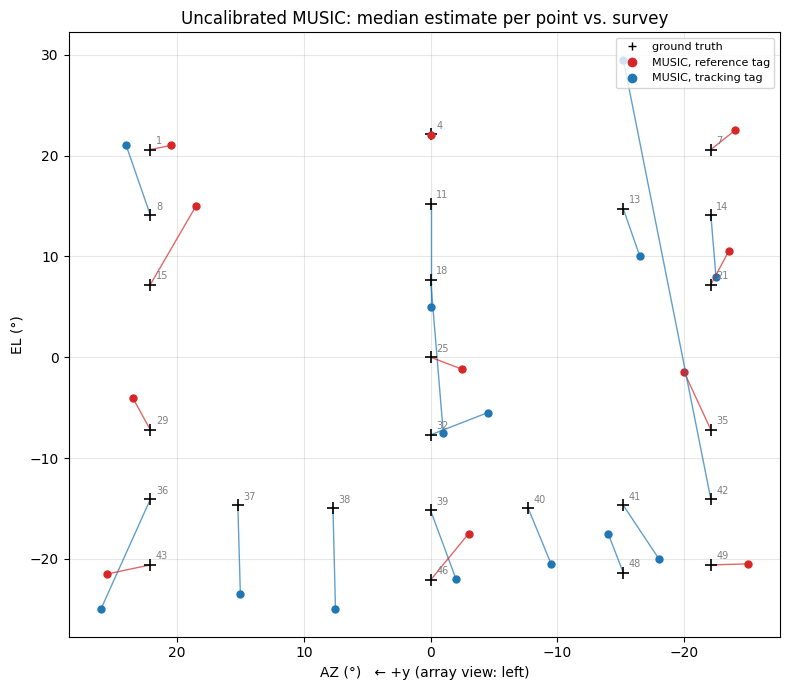

In [17]:
fig, ax = plt.subplots(figsize=(8, 7))
for pt, r in per_pt.iterrows():
    c = 'C3' if r.role == 'ref' else 'C0'
    ax.plot([r.AZ, r.az_med], [r.EL, r.el_med], '-', color=c, lw=1, alpha=0.7)
    ax.plot(r.AZ, r.EL, 'k+', ms=8, mew=1.2)
    ax.plot(r.az_med, r.el_med, 'o', color=c, ms=5)
    ax.annotate(str(pt), (r.AZ, r.EL), textcoords='offset points', xytext=(4, 4), fontsize=7, color='gray')
ax.plot([], [], 'k+', label='ground truth'); ax.plot([], [], 'o', color='C3', label='MUSIC, reference tag'); ax.plot([], [], 'o', color='C0', label='MUSIC, tracking tag')
ax.invert_xaxis(); ax.set_xlabel('AZ (°)   ← +y (array view: left)'); ax.set_ylabel('EL (°)')
ax.set_title('Uncalibrated MUSIC: median estimate per point vs. survey'); ax.legend(loc='upper right', fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

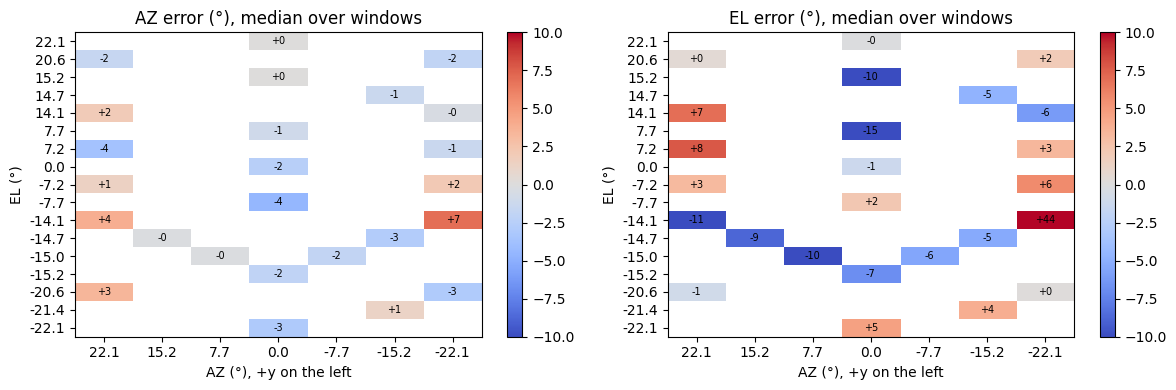

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for a, col, name in [(ax[0], 'az_err', 'AZ'), (ax[1], 'el_err', 'EL')]:
    piv = per_pt.pivot_table(index=per_pt.EL.round(1), columns=per_pt.AZ.round(1), values=col)
    piv = piv.sort_index(ascending=False).sort_index(axis=1, ascending=False)
    im = a.imshow(piv.to_numpy(), cmap='coolwarm', vmin=-10, vmax=10, aspect='auto')
    a.set_xticks(range(piv.shape[1])); a.set_xticklabels(piv.columns); a.set_yticks(range(piv.shape[0])); a.set_yticklabels(piv.index)
    a.set_xlabel('AZ (°), +y on the left'); a.set_ylabel('EL (°)'); a.set_title(f'{name} error (°), median over windows')
    for i in range(piv.shape[0]):
        for j in range(piv.shape[1]):
            v = piv.to_numpy()[i, j]
            if not np.isnan(v): a.text(j, i, f'{v:+.0f}', ha='center', va='center', fontsize=7)
    plt.colorbar(im, ax=a)
plt.tight_layout(); plt.show()

### Repeatability of the reference tags across sets

A reference tag never moves, so its estimate should be the same in every set. Spread here is measurement noise plus anything that changed in the room between recordings.

In [19]:
ref_sets = (est[est.role == 'ref'].groupby(['pt', 'set'])[['az_hat', 'el_hat']].median().round(1))
ref_sets['az_hat'].unstack('set')

set,set1,set2,set3,set4,set5,set6,set7,test
pt,,,,,,,,
1,20.5,20.2,20.5,20.5,20.5,20.5,20.5,20.5
4,0.0,0.0,0.2,0.0,0.0,0.0,0.5,0.5
7,-24.0,-24.0,-24.5,-24.0,-24.0,-24.0,-24.0,-24.5
15,18.5,18.5,18.5,18.5,19.0,18.5,19.0,19.0
21,-23.5,-23.5,-23.5,-24.0,-23.5,-24.0,-23.5,-24.0
25,-3.0,-2.5,-2.5,-2.5,-3.0,-2.5,-2.5,-3.0
29,23.0,24.0,23.5,24.0,23.5,23.8,24.0,23.0
35,-23.0,-20.0,-20.0,-19.5,-20.0,-19.5,-19.5,-22.2
43,25.5,25.5,25.5,26.0,25.5,25.5,25.5,26.5


In [20]:
ref_sets['el_hat'].unstack('set')

set,set1,set2,set3,set4,set5,set6,set7,test
pt,,,,,,,,
1,20.5,20.5,21.0,20.8,20.5,21.0,21.0,21.0
4,21.5,21.5,22.0,22.0,22.0,22.0,22.0,21.8
7,22.5,22.5,22.2,22.5,22.5,22.5,22.5,22.0
15,15.0,15.0,15.0,15.0,15.0,15.0,15.0,15.5
21,10.5,10.5,10.0,10.0,10.5,10.5,10.5,10.5
25,-1.0,-1.5,-1.0,-0.8,-1.5,-1.5,-2.0,-1.2
29,-3.0,-4.0,-4.0,-3.8,-3.5,-3.8,-4.0,-3.5
35,-2.5,-1.5,-2.0,-1.5,-1.5,-1.5,-2.0,-2.8
43,-22.0,-21.5,-22.0,-22.0,-21.5,-22.0,-21.5,-22.5


### Eigenvalue ratio as a quality flag

$\lambda_1/\lambda_2$ measures how single-path the window looks. Points with a low ratio are the multipath candidates for the next steps.

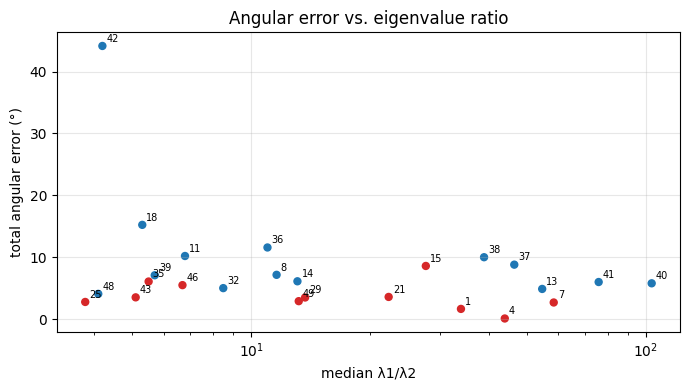

In [21]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(per_pt.ratio, np.hypot(per_pt.az_err, per_pt.el_err), c=np.where(per_pt.role == 'ref', 'C3', 'C0'), s=25)
for pt, r in per_pt.iterrows():
    ax.annotate(str(pt), (r.ratio, np.hypot(r.az_err, r.el_err)), textcoords='offset points', xytext=(3, 3), fontsize=7)
ax.set_xscale('log'); ax.set_xlabel('median λ1/λ2'); ax.set_ylabel('total angular error (°)'); ax.set_title('Angular error vs. eigenvalue ratio')
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 7. Save

In [22]:
est.to_csv('dataset19_uncal_music_windows.csv', index=False)
per_pt.to_csv('dataset19_uncal_music_per_point.csv')
four_way.to_csv('dataset19_four_way_sign_test.csv')
print('wrote dataset19_uncal_music_windows.csv, dataset19_uncal_music_per_point.csv, dataset19_four_way_sign_test.csv')

wrote dataset19_uncal_music_windows.csv, dataset19_uncal_music_per_point.csv, dataset19_four_way_sign_test.csv


## Summary

- The steering vector encodes the ideal phase pattern $\psi_n = 2\pi(d/\lambda)(s_y u y_n + s_z v z_n)$ for each candidate direction; MUSIC finds the direction whose pattern is orthogonal to the noise subspace of the measured covariance.
- The sign convention $(s_y, s_z)$ is measured with the four-way test on the reference tags, not assumed.
- With ideal geometry and no calibration, MUSIC places every point in the right region of the grid: AZ MAE 2.1°, EL MAE 6.8°, window scatter 0.5°.
- The errors are systematic, not random: a row-dependent elevation bias consistent with a floor/ceiling image, and two points (pt18, pt42) where a comparable second arrival inverts the vertical phase gradient and mirrors the elevation. Amplitude normalisation changes nothing, confirming they are phase errors.
- Each error type has a correction route with a different ground-truth cost (element calibration, empirical manifold, image model); GT is needed once to build a correction, and its worth is measured on the held-out tracking tags.
- The eigenvalue ratio $\lambda_1/\lambda_2$ flags windows with a second arrival.